In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import yfinance as yf

register_matplotlib_converters()

[*********************100%***********************]  1 of 1 completed


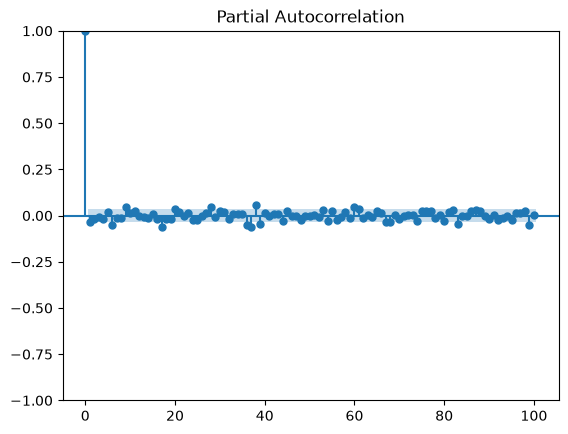

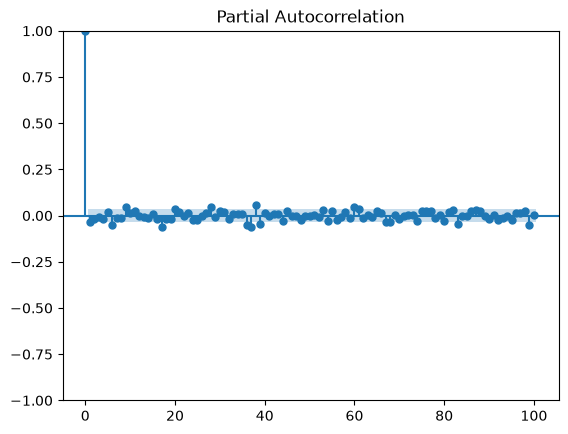

In [2]:
tickersymbol = 'MSFT'

tickerDF = yf.download(start='2015-1-1', tickers=tickersymbol, interval='1d', group_by='column', auto_adjust=True)

tickerDF = pd.DataFrame(tickerDF)

if isinstance(tickerDF.columns, pd.MultiIndex):
    tickerDF.columns = tickerDF.columns.get_level_values(0)

close = tickerDF['Close']


first_diffs = close[1:] - close[:-1]

first_diffs = close.diff().fillna(0)

tickerDF['First_Diff'] = first_diffs

tickerDF.head

# plot_acf(tickerDF.First_Diff, lags=100)

plot_pacf(tickerDF.First_Diff, lags=100)


In [ ]:
from statsmodels.tsa.stattools import adfuller

def dickey_fuller(t_series):
    result = adfuller(t_series)

    return result[0], result[1]

adf_statistic, p_value = dickey_fuller(first_diffs)

print(adf_statistic)
print(p_value)


# p_value negligibly low - proving stationarity by hypothesis test

-12.358023408529288
5.628544542886617e-23
